# 18 — Autoencoders & a Conceptual Intro to GANs/VAEs

Every model so far has been trained to predict something — a label, a
future value. This notebook covers **generative** models: networks trained
to model the data distribution itself, well enough to *reconstruct* or even
*generate* new examples. This is a lighter, survey-style module rather than
a deep dive — enough to build real intuition and see each idea work at
least once, not a production-grade implementation of any of them.

**Covered:**
1. Autoencoders: compressing and reconstructing data
2. The latent space, vs. PCA/t-SNE (`05_unsupervised_learning`)
3. Denoising autoencoders
4. Variational Autoencoders (VAEs): a structured latent space you can sample from
5. Generative Adversarial Networks (GANs): a conceptual intro + a minimal working demo

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

sns.set_theme(style="whitegrid")
torch.manual_seed(18)
rng = np.random.default_rng(18)

## 1. Autoencoders

**Theory.** An autoencoder has two parts: an **encoder** that compresses
input `x` into a lower-dimensional **latent** vector `z`, and a **decoder**
that tries to reconstruct `x` from `z` alone. Trained purely to minimize
reconstruction error, with no labels at all — the "supervision" signal is
the input itself. If reconstruction works well through a narrow bottleneck,
the network has been forced to learn a compressed representation that
captures the data's essential structure.

In [2]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

digits = load_digits()
X = digits.data.astype("float32")
X_scaled = MinMaxScaler().fit_transform(X)  # scale to [0, 1] to match a sigmoid decoder output
X_train, X_test, y_train, y_test = train_test_split(X_scaled, digits.target, test_size=0.2, random_state=18)
X_train_t, X_test_t = torch.tensor(X_train), torch.tensor(X_test)

In [3]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, latent_dim))
        self.decoder = nn.Sequential(nn.Linear(latent_dim, 32), nn.ReLU(), nn.Linear(32, 64), nn.Sigmoid())

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

model = Autoencoder(latent_dim=8)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for _ in range(200):
    model.train()
    optimizer.zero_grad()
    recon, _ = model(X_train_t)
    loss = criterion(recon, X_train_t)
    loss.backward()
    optimizer.step()

model.eval()
with torch.no_grad():
    recon_test, z_test = model(X_test_t)
    test_mse = criterion(recon_test, X_test_t).item()
print(f"Test reconstruction MSE: {test_mse:.4f}  (64 features compressed to just 8)")

Test reconstruction MSE: 0.0539  (64 features compressed to just 8)


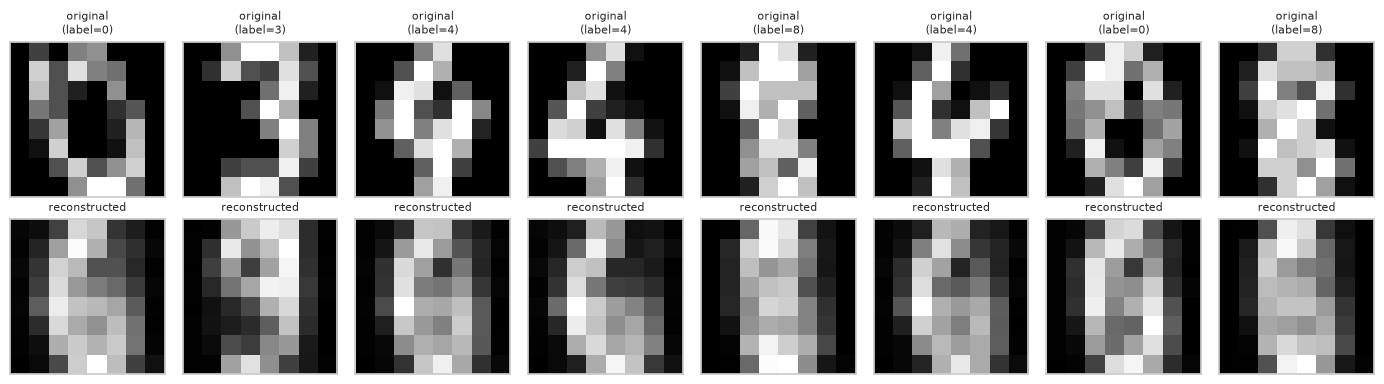

In [4]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(X_test[i].reshape(8, 8), cmap="gray")
    axes[0, i].set_title(f"original\n(label={y_test[i]})", fontsize=8)
    axes[1, i].imshow(recon_test[i].detach().numpy().reshape(8, 8), cmap="gray")
    axes[1, i].set_title("reconstructed", fontsize=8)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

Reconstructions are blurrier than the originals (some detail is
necessarily lost squeezing 64 pixels through an 8-dimensional bottleneck),
but the digit's core shape survives — evidence the 8 latent numbers are
capturing genuinely useful structure, not noise.

## 2. The Latent Space, vs. PCA/t-SNE

**Theory.** `05_unsupervised_learning` used PCA (linear) and t-SNE
(non-linear, visualization-only) to compress data for plotting. An
autoencoder's latent space is a third option: **non-linear**, but (unlike
t-SNE) with an actual decoder attached, so points in latent space can be
mapped back to data space — including points the network never saw during
training.

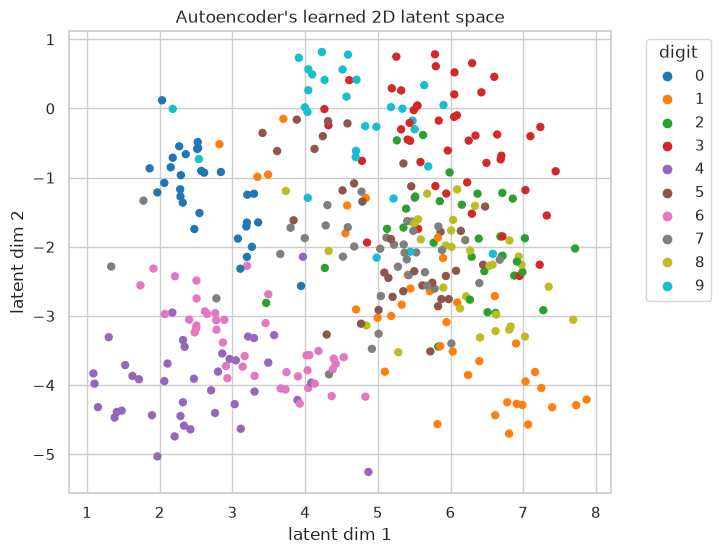

In [5]:
latent_model = Autoencoder(latent_dim=2)  # 2D bottleneck, small enough to plot directly
optimizer = torch.optim.Adam(latent_model.parameters(), lr=0.001)
for _ in range(300):
    latent_model.train()
    optimizer.zero_grad()
    recon, _ = latent_model(X_train_t)
    loss = criterion(recon, X_train_t)
    loss.backward()
    optimizer.step()

latent_model.eval()
with torch.no_grad():
    _, z_2d = latent_model(X_test_t)
z_2d = z_2d.numpy()

plt.figure(figsize=(7, 6))
scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=y_test, cmap="tab10", s=25)
plt.legend(*scatter.legend_elements(), title="digit", bbox_to_anchor=(1.05, 1))
plt.xlabel("latent dim 1")
plt.ylabel("latent dim 2")
plt.title("Autoencoder's learned 2D latent space")
plt.show()

Similar digits cluster together, much like the PCA/t-SNE plots from
`05_unsupervised_learning` — but notice how uneven and gappy this space
is: some regions are dense, others nearly empty. That gappiness is exactly
the problem VAEs (section 4) are designed to fix.

## 3. Denoising Autoencoders

**Theory.** A small change to training makes autoencoders more robust and
genuinely useful for cleanup tasks: feed the network a **corrupted**
(noisy) input, but train it to reconstruct the **clean, original**
version. The network can't just learn identity mapping — it has to learn
what the underlying signal actually looks like, discarding the noise.

In [6]:
def add_noise(x, noise_factor=0.4):
    noisy = x + noise_factor * torch.randn_like(x)
    return torch.clamp(noisy, 0.0, 1.0)

denoiser = Autoencoder(latent_dim=16)
optimizer = torch.optim.Adam(denoiser.parameters(), lr=0.001)

for _ in range(300):
    denoiser.train()
    optimizer.zero_grad()
    noisy_input = add_noise(X_train_t)
    recon, _ = denoiser(noisy_input)
    loss = criterion(recon, X_train_t)  # reconstruct the CLEAN target, from a NOISY input
    loss.backward()
    optimizer.step()

denoiser.eval()
noisy_test = add_noise(X_test_t)
with torch.no_grad():
    denoised_test, _ = denoiser(noisy_test)

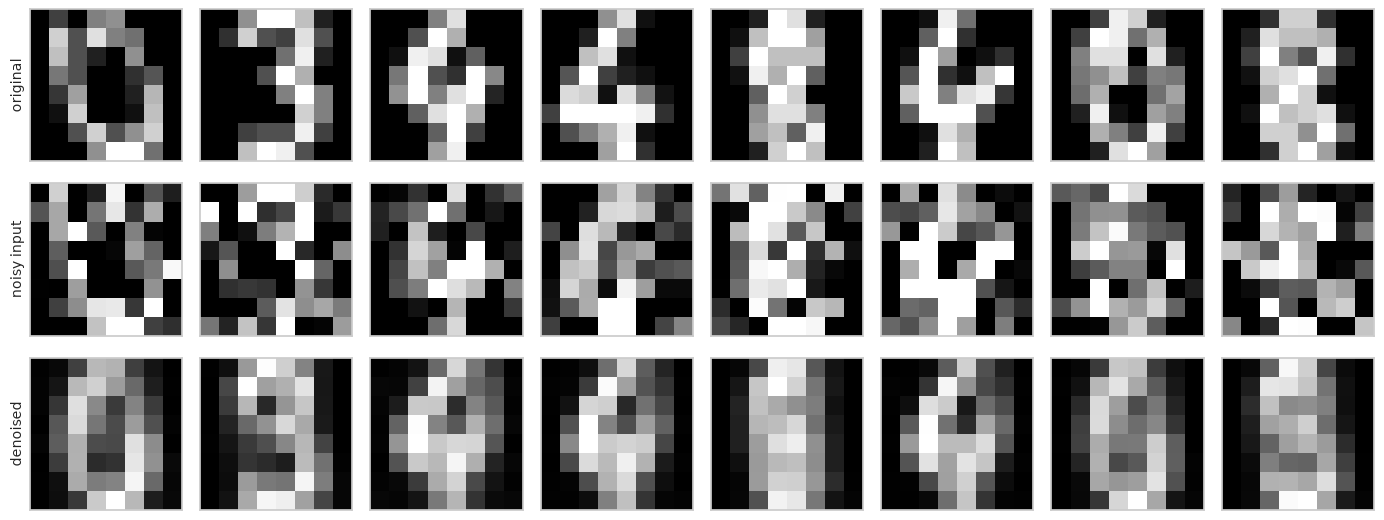

In [7]:
fig, axes = plt.subplots(3, 8, figsize=(14, 5.5))
for i in range(8):
    axes[0, i].imshow(X_test[i].reshape(8, 8), cmap="gray")
    axes[1, i].imshow(noisy_test[i].numpy().reshape(8, 8), cmap="gray")
    axes[2, i].imshow(denoised_test[i].numpy().reshape(8, 8), cmap="gray")
axes[0, 0].set_ylabel("original", fontsize=10)
axes[1, 0].set_ylabel("noisy input", fontsize=10)
axes[2, 0].set_ylabel("denoised", fontsize=10)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

## 4. Variational Autoencoders (VAEs)

**Theory.** A vanilla autoencoder's latent space (section 2) has no
constraint on its shape — the network is free to leave gaps, which means
sampling a *random* latent point and decoding it usually produces garbage,
since that point may sit somewhere the decoder never learned to handle.

A **VAE** fixes this by making the encoder output a **distribution**
(mean `mu` and log-variance `logvar`) rather than a single point, and
adding a regularization term (KL divergence) that pushes every input's
distribution toward a standard normal `N(0, 1)`. To keep sampling
differentiable during training, VAEs use the **reparameterization trick**:
`z = mu + eps * std`, where `eps ~ N(0,1)` is random noise injected
*outside* the computation graph, so gradients can still flow through `mu`
and `std`.

The result: a latent space with no gaps — *any* point sampled from
`N(0, 1)` decodes to something plausible.

In [8]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.shared = nn.Sequential(nn.Linear(64, 32), nn.ReLU())
        self.fc_mu = nn.Linear(32, latent_dim)
        self.fc_logvar = nn.Linear(32, latent_dim)
        self.decoder = nn.Sequential(nn.Linear(latent_dim, 32), nn.ReLU(), nn.Linear(32, 64), nn.Sigmoid())

    def encode(self, x):
        h = self.shared(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)   # the randomness lives HERE, outside the graph -- mu/std stay differentiable
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

def vae_loss(recon, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(recon, x, reduction="sum") / x.size(0)
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + kl_divergence, recon_loss, kl_divergence

torch.manual_seed(18)  # reset here so this section's result doesn't depend on how many random calls earlier cells made
vae = VAE(latent_dim=2)
optimizer = torch.optim.Adam(vae.parameters(), lr=0.001)

for _ in range(1000):
    vae.train()
    optimizer.zero_grad()
    recon, mu, logvar = vae(X_train_t)
    loss, _, _ = vae_loss(recon, X_train_t, mu, logvar)
    loss.backward()
    optimizer.step()

vae.eval()
with torch.no_grad():
    recon_test, mu_test, logvar_test = vae(X_test_t)
    total, rl, kl = vae_loss(recon_test, X_test_t, mu_test, logvar_test)
print(f"Test loss: {total.item():.2f}  (reconstruction={rl.item():.2f}, KL={kl.item():.2f})")

Test loss: 25.28  (reconstruction=23.27, KL=2.01)


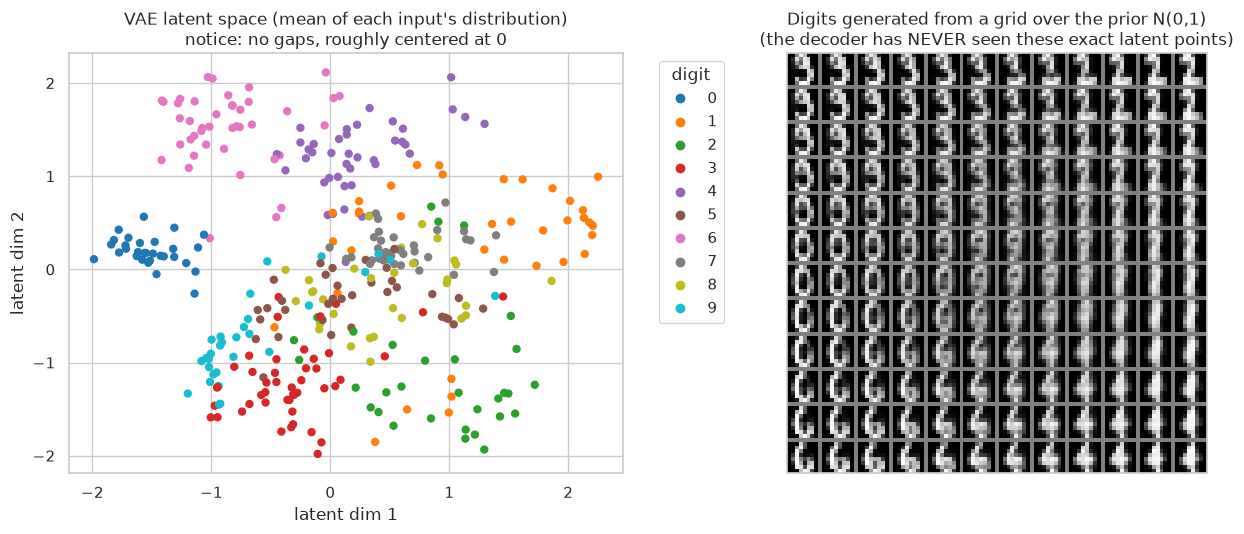

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

with torch.no_grad():
    mu_all, _ = vae.encode(X_test_t)
scatter = axes[0].scatter(mu_all[:, 0], mu_all[:, 1], c=y_test, cmap="tab10", s=25)
axes[0].legend(*scatter.legend_elements(), title="digit", bbox_to_anchor=(1.05, 1))
axes[0].set_title("VAE latent space (mean of each input's distribution)\nnotice: no gaps, roughly centered at 0")
axes[0].set_xlabel("latent dim 1"); axes[0].set_ylabel("latent dim 2")

# Sample a grid directly from the N(0,1) prior and decode EVERY point -- no real input involved.
# Tiles are stitched with a thin gray gap between them: with NO gap, adjacent 8x8 tiles create a
# Moire-like illusion of vertical stripes even when every individual tile is a perfectly fine digit --
# worth remembering any time you tile many small images into one array for display.
grid_size = 12
tile_size, gap = 8, 1
grid_x = np.linspace(-2.5, 2.5, grid_size)
grid_y = np.linspace(-2.5, 2.5, grid_size)
canvas_size = grid_size * (tile_size + gap) - gap
canvas = np.full((canvas_size, canvas_size), 0.5)  # mid-gray gap background
with torch.no_grad():
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float32)
            digit = vae.decoder(z_sample).numpy().reshape(8, 8)
            r0, c0 = i * (tile_size + gap), j * (tile_size + gap)
            canvas[r0:r0 + tile_size, c0:c0 + tile_size] = digit
axes[1].imshow(canvas, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
axes[1].set_title("Digits generated from a grid over the prior N(0,1)\n(the decoder has NEVER seen these exact latent points)")
axes[1].set_xticks([]); axes[1].set_yticks([])
plt.tight_layout()
plt.show()

Every tile in the right panel is generated from a latent point picked
*without reference to any real image* — purely by walking a grid across
the prior distribution the VAE was trained to match. Nearby points decode
to visually similar digits, and the transitions between digit clusters are
smooth — exactly the well-organized, sample-able latent space a vanilla
autoencoder (section 2) doesn't guarantee.

## 5. Generative Adversarial Networks (GANs)

**Theory.** A GAN trains two networks against each other:
- The **Generator** takes random noise and tries to produce fake samples realistic enough to fool the discriminator.
- The **Discriminator** tries to correctly tell real data apart from the generator's fakes.

They're trained in alternation, as an adversarial (minimax) game: the
generator improves by learning to exploit the discriminator's weaknesses,
and the discriminator improves by catching the generator's current
weaknesses — ideally converging to a generator whose fakes are
indistinguishable from real data. Unlike a VAE, there's no explicit
reconstruction loss at all — the discriminator's judgment *is* the
training signal.

Full image-quality GANs need substantial compute and tuning, well beyond
this notebook's scope — but the core adversarial training loop is
compact enough to see working directly on a simple 2D distribution: a
ring of points, easy to visualize and easy to judge success or failure by eye.

In [10]:
def sample_ring(n):
    angles = rng.uniform(0, 2 * np.pi, n)
    radius = 2 + rng.normal(0, 0.1, n)
    points = np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)
    return torch.tensor(points, dtype=torch.float32)

class Generator(nn.Module):
    def __init__(self, noise_dim=4):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(noise_dim, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 2))

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 1))

    def forward(self, x):
        return self.net(x)

noise_dim = 4
G, D = Generator(noise_dim), Discriminator()
opt_g = torch.optim.Adam(G.parameters(), lr=0.0005, betas=(0.5, 0.999))
opt_d = torch.optim.Adam(D.parameters(), lr=0.0005, betas=(0.5, 0.999))
criterion = nn.BCEWithLogitsLoss()
batch_size = 128

snapshots = {}
for epoch in range(5000):
    # --- train the discriminator: tell real ring points from the generator's fakes ---
    real = sample_ring(batch_size)
    fake = G(torch.randn(batch_size, noise_dim)).detach()
    d_loss = (criterion(D(real), torch.full((batch_size, 1), 0.9)) +   # 0.9 instead of 1.0: label smoothing, a standard GAN stabilizer
              criterion(D(fake), torch.zeros(batch_size, 1)))
    opt_d.zero_grad(); d_loss.backward(); opt_d.step()

    # --- train the generator: try to fool the (just-updated) discriminator ---
    fake = G(torch.randn(batch_size, noise_dim))
    g_loss = criterion(D(fake), torch.ones(batch_size, 1))
    opt_g.zero_grad(); g_loss.backward(); opt_g.step()

    if epoch in (0, 500, 2000, 4999):
        with torch.no_grad():
            snapshots[epoch] = G(torch.randn(300, noise_dim)).numpy()

print("Training complete.")

Training complete.


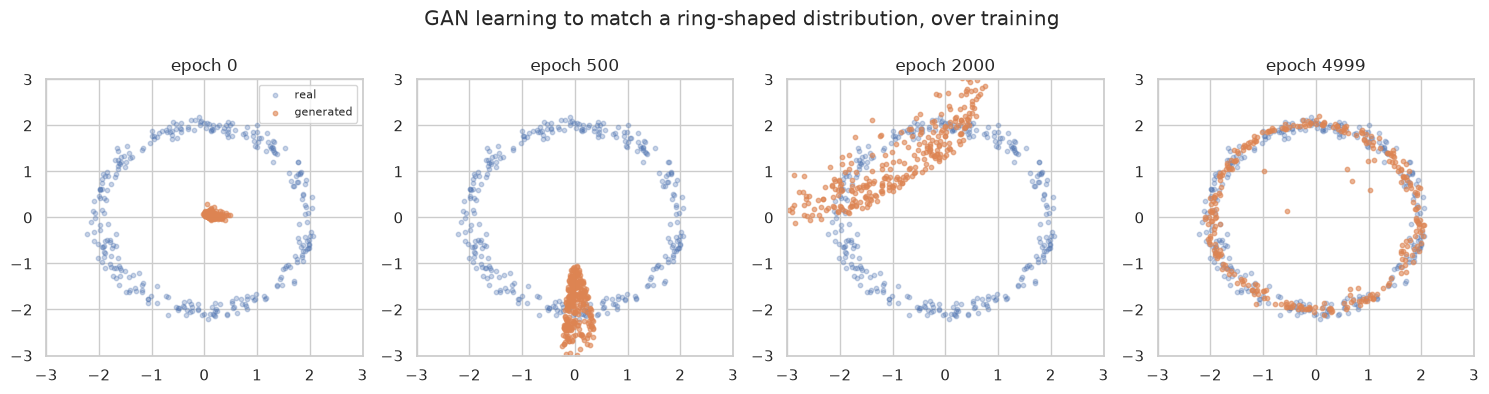

In [11]:
real_points = sample_ring(300).numpy()

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, (epoch, gen_points) in zip(axes, snapshots.items()):
    ax.scatter(real_points[:, 0], real_points[:, 1], s=10, alpha=0.3, label="real")
    ax.scatter(gen_points[:, 0], gen_points[:, 1], s=10, alpha=0.6, label="generated")
    ax.set_title(f"epoch {epoch}")
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
axes[0].legend(loc="upper right", fontsize=8)
plt.suptitle("GAN learning to match a ring-shaped distribution, over training")
plt.tight_layout()
plt.show()

At epoch 0 the generator's output is just noise clustered near the origin
(a fresh random network); by the final snapshot, its samples trace the
same ring the real data occupies — the discriminator's ability to catch
fakes has driven the generator to actually learn the target distribution's
shape, without ever being shown "the answer" (a target coordinate) the way
a supervised or reconstruction-based model would be.

## Exercises

1. In section 1, reduce `latent_dim` from 8 to 2 and compare reconstruction quality — how much blurrier do the digits get?
2. In section 4, try decoding a few points *outside* the `[-2.5, 2.5]` grid range (e.g., `[5, 5]`) — does the VAE still produce something digit-like, or does quality degrade far from where the prior concentrates its mass?
3. In section 5, remove the `0.9` label smoothing (use `1.0` instead) and retrain — does the discriminator loss behave differently (check if it collapses toward 0, a sign the discriminator is "winning" too easily)?

## Key Takeaways

- Autoencoders learn compressed representations purely from reconstruction error — no labels needed.
- A vanilla autoencoder's latent space can have gaps; a VAE's KL-regularized latent space is specifically built to avoid them, which is what makes sampling new, plausible data possible.
- The reparameterization trick is what lets randomness participate in a VAE's forward pass without blocking gradients from flowing through the encoder.
- GANs replace an explicit reconstruction loss with an adversarial one — a discriminator's judgment drives the generator to match a target distribution, demonstrated end-to-end here even though production-scale image GANs are out of this notebook's scope.